# A/B Test Analysis: E-Commerce Conversion Rate

## Project Overview

This analysis examines the results of an A/B test conducted by an e-commerce company. The company developed a new web page to increase the number of users who convert (i.e., decide to pay for the product). The goal is to determine whether the new page performs better than the existing page, and whether geographic location influences conversion rates.

## Table of Contents
- [Part I - Descriptive Statistics](#part-i)
- [Part II - Probability](#part-ii)
- [Part III - Hypothesis Testing](#part-iii)
- [Part IV - Logistic Regression](#part-iv)

## Dataset
- **Source:** `ab_data.csv`
- **Rows:** 69,889 user sessions
- **Columns:** `country`, `group` (control/treatment), `converted` (0/1)


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
random.seed(0)

In [2]:
# Load the dataset
df = pd.read_csv('ab_data.csv')
df.head()

,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


---
<a id='part-i'></a>
## Part I — Descriptive Statistics


In [3]:
# Total number of records
print('Total rows:', df.shape[0])

# Overall conversion rate
print('Overall conversion rate:', round(df['converted'].mean() * 100, 2), '%')

# Check for missing values
print('\nMissing values:')
print(df.isnull().sum())

Total rows: 69889
Overall conversion rate: 13.05 %

Missing values:
country      0
group        0
converted    0
dtype: int64


country
US    48850
UK    17551
CA     3488
Name: count, dtype: int64


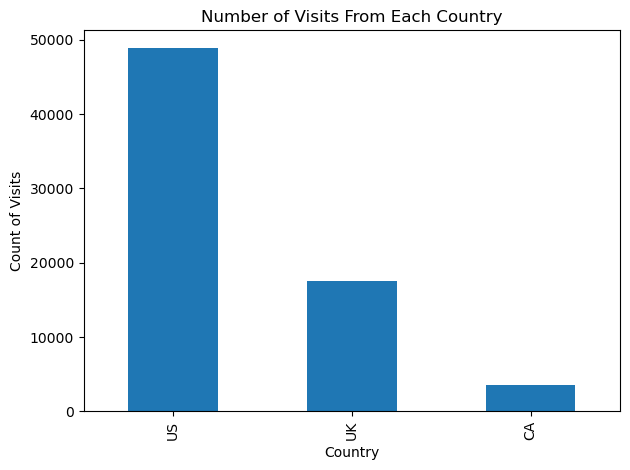

In [4]:
# Number of visitors from each country
print(df['country'].value_counts())

# Visualize country distribution
df['country'].value_counts().plot(kind='bar')
plt.title('Number of Visits From Each Country')
plt.ylabel('Count of Visits')
plt.xlabel('Country')
plt.tight_layout()
plt.show()

In [5]:
# Check data types
df.dtypes

country      object
group        object
converted     int64
dtype: object

The `converted` column is the only non-categorical column. It is stored as `int64` because it contains numerical values (0 and 1) rather than category labels. All other columns contain categorical string values.


In [6]:
# Possible values of the converted column
df['converted'].unique()

array([0, 1])

The `converted` column only contains values of **0** and **1**. This makes sense because conversion is a binary outcome — a user either completed a purchase (1) or did not (0). There is no middle ground for this type of decision.


---
<a id='part-ii'></a>
## Part II — Probability


In [7]:
# Overall conversion probability
overall_conversion = df['converted'].mean()
print(f'Overall conversion rate: {overall_conversion:.2%}')

# Conversion rate by group
control_rate = df.query('group == "control"')["converted"].mean()
treatment_rate = df.query('group == "treatment"')["converted"].mean()
print(f'Control group conversion rate: {control_rate:.2%}')
print(f'Treatment group conversion rate: {treatment_rate:.2%}')
print(f'Delta (Treatment - Control): {(treatment_rate - control_rate):.2%}')

Overall conversion rate: 13.05%
Control group conversion rate: 10.53%
Treatment group conversion rate: 15.53%
Delta (Treatment - Control): 5.01%


The treatment group shows a **15.5%** conversion rate compared to **10.5%** for the control group — a difference of approximately **5%**. While this suggests the new page may be associated with higher conversions, further statistical testing is needed to determine whether this difference is statistically significant or could be due to random chance.


In [8]:
# Group size distribution
print('Treatment group size:', df.query('group == "treatment"').shape[0])
print('Control group size:', df.query('group == "control"').shape[0])
print('Probability of being in treatment:', round(df.query('group == "treatment"').shape[0] / df.shape[0], 4))

Treatment group size: 35211
Control group size: 34678
Probability of being in treatment: 0.5038


In [9]:
# Conversion rate by country
print('Conversion rates by country:')
print(df.groupby('country')['converted'].mean().apply(lambda x: f'{x:.2%}'))

# Probability of being from Canada
ca_prob = df.query('country == "CA"').shape[0] / df.shape[0]
print(f'\nProbability of being from CA: {ca_prob:.2%}')

Conversion rates by country:
country
CA    12.53%
UK    12.51%
US    13.28%
Name: converted, dtype: object

Probability of being from CA: 4.99%


Conversion rates are very similar across all three countries (12-13%), suggesting that country alone does not meaningfully impact conversion rates.


In [10]:
# Conversion rates by country AND group
print('Conversion rates by country and group:\n')

for country in ['US', 'UK', 'CA']:
    control = df.query(f'country == "{country}" and group == "control"')['converted'].mean()
    treatment = df.query(f'country == "{country}" and group == "treatment"')['converted'].mean()
    print(f'{country} - Control: {control:.1%} | Treatment: {treatment:.1%}')

Conversion rates by country and group:

US - Control: 10.7% | Treatment: 15.8%
UK - Control: 10.2% | Treatment: 14.9%
CA - Control: 9.4% | Treatment: 15.4%


|             | US    | UK    | CA    |
| ----------- | ----- | ----- | ----- |
| Control     | 10.7% | 10.2% | 9.4%  |
| Treatment   | 15.8% | 14.8% | 15.4% |

The treatment group consistently outperforms the control group by approximately 5% across all three countries. Since the gap is similar regardless of country, there does not appear to be a significant interaction between country and treatment impact on conversion rates.


---
<a id='part-iii'></a>
## Part III — Hypothesis Testing

We use a simulation-based hypothesis test to determine whether the observed difference in conversion rates is statistically significant.

**Hypotheses:**
- $H_0$: $p_{treatment} - p_{control} \leq 0$ (new page is no better)
- $H_1$: $p_{treatment} - p_{control} > 0$ (new page converts better)

**Type I error rate:** 0.05


In [11]:
# Set up null hypothesis parameters
p_null = df['converted'].mean()  # conversion rate under null
n_treatment = df.query('group == "treatment"').shape[0]
n_control = df.query('group == "control"').shape[0]

print(f'Null conversion rate: {p_null:.4f}')
print(f'Treatment group size: {n_treatment}')
print(f'Control group size: {n_control}')

Null conversion rate: 0.1305
Treatment group size: 35211
Control group size: 34678


In [12]:
# Simulate 500 differences under the null hypothesis
p_diffs = []
for _ in range(500):
    treatment_converted = list(np.random.choice([0, 1], size=n_treatment,
                               p=[1-p_null, p_null]))
    control_converted = list(np.random.choice([0, 1], size=n_control,
                             p=[1-p_null, p_null]))
    p_diff = np.mean(treatment_converted) - np.mean(control_converted)
    p_diffs.append(p_diff)

p_diffs = np.array(p_diffs)
print(f'Simulations completed: {len(p_diffs)}')

Simulations completed: 500


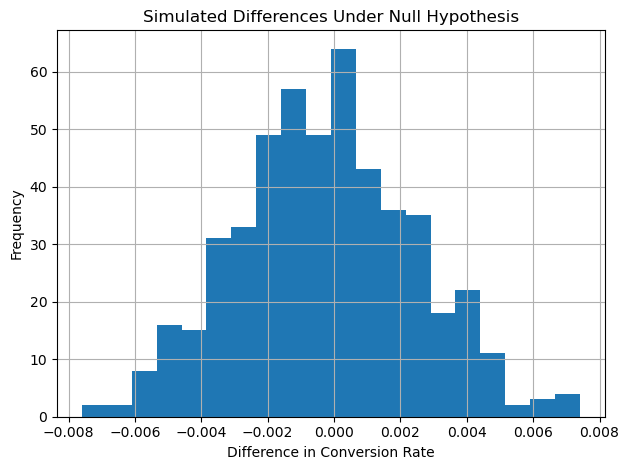

In [13]:
# Plot distribution of simulated differences
p_diffs_series = pd.Series(p_diffs)
p_diffs_series.hist(bins=20)
plt.title('Simulated Differences Under Null Hypothesis')
plt.xlabel('Difference in Conversion Rate')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [14]:
# Calculate actual observed difference and p-value
actual_diff = df.query('group == "treatment"')['converted'].mean() - \
              df.query('group == "control"')['converted'].mean()

p_value = (p_diffs > actual_diff).mean()
print(f'Observed difference: {actual_diff:.4f} ({actual_diff:.2%})')
print(f'P-value: {p_value}')

Observed difference: 0.0501 (5.01%)
P-value: 0.0


**Results:**

The observed difference in conversion rates between the treatment and control groups was **5%**. Across 500 simulations under the null hypothesis, none produced a difference this large, yielding a **p-value of 0.0**.

Since the p-value (0.0) is below our Type I error rate of 0.05, we **reject the null hypothesis**. The evidence suggests the treatment page leads to a statistically significantly higher conversion rate than the control page.


---
<a id='part-iv'></a>
## Part IV — Logistic Regression

Since the outcome variable (`converted`) is binary, **logistic regression** is the appropriate model. We use `statsmodels` to confirm the findings from Part III and additionally assess whether country plays a role in conversion.


In [15]:
# Prepare data for logistic regression
df['intercept'] = 1
df['ab_page'] = pd.get_dummies(df['group'])['treatment'].astype(int)
df.head()

,country,group,converted,intercept,ab_page
0,UK,control,0,1,0
1,US,treatment,1,1,1
2,UK,treatment,0,1,1
3,UK,control,0,1,0
4,UK,treatment,0,1,1


In [16]:
import statsmodels.api as sm

# Model 1: Page effect only
X = df[['intercept', 'ab_page']]
y = df['converted']

logit_mod = sm.Logit(y, X)
logit_res = logit_mod.fit()
print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.384516
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                69889
Model:                          Logit   Df Residuals:                    69887
Method:                           MLE   Df Model:                            1
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                0.007175
Time:                        02:27:12   Log-Likelihood:                -26873.
converged:                       True   LL-Null:                       -27068.
Covariance Type:            nonrobust   LLR p-value:                 1.810e-86
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.1402      0.017   -122.305      0.000      -2.174      -2.106
ab_page        0.4467      0.

The p-value for `ab_page` is **0.000**, confirming the finding from Part III. We reject the null hypothesis — the treatment page is associated with a statistically significant increase in conversion rates.


In [17]:
# Model 2: Page effect + country
df[['US', 'UK']] = pd.get_dummies(df['country'])[['US', 'UK']].astype(int)

X2 = df[['intercept', 'ab_page', 'US', 'UK']]
y2 = df['converted']

logit_mod2 = sm.Logit(y2, X2)
logit_res2 = logit_mod2.fit()
print(logit_res2.summary())

Optimization terminated successfully.
         Current function value: 0.384463
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                69889
Model:                          Logit   Df Residuals:                    69885
Method:                           MLE   Df Model:                            3
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                0.007312
Time:                        02:27:12   Log-Likelihood:                -26870.
converged:                       True   LL-Null:                       -27068.
Covariance Type:            nonrobust   LLR p-value:                 1.778e-85
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.1930      0.053    -41.308      0.000      -2.297      -2.089
ab_page        0.4466      0.

**Country Analysis Results:**

The p-values for `US` (0.170) and `UK` (0.905) are both well above our threshold of 0.05, indicating that country is **not** a statistically significant predictor of conversion. Adding country to the model does not change our conclusion about the treatment page — the `ab_page` effect remains significant (p=0.000).


---
## Conclusions

1. **The new page shows a statistically significant improvement in conversion rates.** The treatment group converted at 15.5% vs 10.5% for the control group — a 5% difference confirmed by both hypothesis testing (p-value = 0.0) and logistic regression (p=0.000).

2. **Country does not significantly impact conversion.** All three countries (US, UK, CA) showed similar overall conversion rates of 12-13%, and logistic regression confirmed country is not a significant predictor (US p=0.170, UK p=0.905).

3. **Recommendation:** Based on this analysis, the company has strong statistical evidence to implement the new treatment page. However, the practical significance of a 5% lift should be evaluated against implementation costs before making a final business decision.

## Resources
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [NumPy Documentation](https://numpy.org/doc/)
- [Statsmodels Documentation](https://www.statsmodels.org/stable/)
- [Matplotlib Documentation](https://matplotlib.org/stable/index.html)
